In [83]:
%pip install langchain-openai langgraph --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [84]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
import operator
from pprint import pprint
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END
from langgraph.types import Send

In [85]:
!pip3 install litellm --break-system-packages

import litellm
litellm.ssl_verify = False

In [86]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [87]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="openai/gpt-oss-120b:groq"
)

### Orchestrator-Worker Pattern

The orchestrator-worker pattern handles complex, variable tasks by decomposing them into structured subtasks and running specialized workers in parallel. It’s ideal when subtask count and scope are unknown in advance (for example, Watsonx Orchestrate-style workflows).

The orchestrator analyzes input, creates clear task briefs, dispatches workers, then aggregates outputs.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/XKXeMzLe9KNW5UjYiJpuSQ/orchestration.png" width="100%" alt="orchestration">

##### Structured Output

Structured output is essential so workers receive predictable inputs and return reliable results.  
In the meal-planning example, each worker returns a `Dish` with:
- dish name  
- ingredient list  
- cuisine/origin  

All results are collected as a `Dishes` list.

In [88]:
# Dish schema for a single dish
class Dish(BaseModel):
    name: str = Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)."
    )
    ingredients: List[str] = Field(
        description="List of ingredients needed for this dish, separated by commas."
    )
    location: str = Field(
        description="The cuisine or cultural origin of the dish (for example, Italian, Indian, Mexican)."
    )

# Dishes schema for a list of Dish objects
class Dishes(BaseModel):
    sections: List[Dish] = Field(
        description="A list of grocery sections, one for each dish, with ingredients."
    )

In [89]:
# construct a prompt template
dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list.\n\n"
        "The user wants to prepare the following meals: {meals}\n\n"
        "For each meal, return a section with:\n"
        "- the name of the dish\n"
        "- a comma-separated list of ingredients needed for that dish.\n"
        "- the cuisine or cultural origin of the food"
    )
])

# use LCEL to pipe the prompt to an LLM with a structured output of Dishes
planner_pipe = dish_prompt | llm.with_structured_output(Dishes)

# invoke the planner_pipe with example meals
planner_pipe.invoke({ "meals" : ["banana smoothie", "carrot cake"]})

Dishes(sections=[Dish(name='Banana Smoothie', ingredients=['bananas', 'milk', 'honey', 'ice cubes'], location='American'), Dish(name='Carrot Cake', ingredients=['carrots', 'flour', 'sugar', 'eggs', 'vegetable oil', 'baking powder', 'cinnamon', 'walnuts', 'cream cheese', 'butter', 'powdered sugar', 'vanilla extract'], location='American')])

##### State (Orchestration)

In LangGraph, **state** is shared memory passed across nodes, holding context like user goals, intermediate outputs, routing signals, and final results. It lets agents read and update the same evolving context so workflows can branch, loop, retry, and make dynamic decisions across multi-step execution.

In [90]:
class State(TypedDict):
    meals: str  # The user's input listing the meals to prepare
    sections: List[Dish] # One section per meal/dish with ingredients
    completed_menu: Annotated[List[str], operator.add]  # Worker written dish guide chunks
    final_meal_guide: str  # Fully compiled, readable menu

In [91]:
# create a dummy state to test our worker nodes
dummy_state: State = {
    "meals": "Spaghetti Bolognese and Chicken Stir Fry",
    "sections": [],
    "completed_menu": [],
    "final_meal_guide": ""
}

report_sections = planner_pipe.invoke({"meals": dummy_state['meals']})

In [92]:
for i, section in enumerate(report_sections.sections):
    print(f"Dish {i+1}\n")
    # add each dish to our dummy state
    dummy_state["sections"].append(section)
    print(f"Item Name: {section.name}")
    print(f"Location/Cuisine: {section.location}")
    print(f"Ingredients: {", ".join(section.ingredients)}.")

Dish 1

Item Name: Spaghetti Bolognese
Location/Cuisine: Italian
Ingredients: spaghetti, ground beef, onion, garlic, carrot, celery, canned tomatoes, tomato paste, olive oil, red wine, beef broth, salt, pepper, oregano, basil, parmesan cheese.
Dish 2

Item Name: Chicken Stir Fry
Location/Cuisine: Chinese
Ingredients: chicken breast, bell pepper, broccoli, carrot, snap peas, onion, garlic, ginger, soy sauce, oyster sauce, sesame oil, vegetable oil, cornstarch, rice vinegar, honey, chili flakes, green onions, rice.


##### Orchestrator Node

The **orchestrator** is the central planner: it takes raw user input, uses an LLM to decompose it into structured `Dish` subtasks, and returns them in `sections` for workers. This enables fan-out parallel execution, where workers process subtasks independently.

In [93]:
def orchestrator(state: State):
    """Orchestrator that generates a structured dish list from the given meals."""

    # use the planner_pipe LLM to break the user's meal list into structured dish sections
    dish_descriptions = planner_pipe.invoke({"meals": state["meals"]})

    # return the list of dish sections to be passed to worker nodes
    return {"sections": dish_descriptions.sections}

##### Worker Nodes

Each **worker node** handles one item from `state["sections"]`. Here, each chef worker takes a single `Dish`, uses an LLM to produce detailed recipe instructions, and writes the result to `state["completed_menu"]`. Workers stay isolated to their assigned slice of state.

In [94]:
chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n"
        "Your response should include:\n"
        "- Start with hello with your  name and culinary background\n"
        "- A clear list of preparation steps\n"
        "- A full explanation of the cooking process\n\n"
        "Use the following ingredients: {ingredients}."
    )
])

chef_pipe = chef_prompt | llm

In [95]:
class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[list, operator.add] # list with addition operators between elements

In [96]:
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("chef_worker", {"section": s}) for s in state["sections"]]

In [97]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}


In [98]:
dummy_dishes: List[Dish] = dummy_state["sections"]

# simulate LangGraph's fan-out and merging behavior
for section in dummy_dishes:
    # construct individual WorkerState
    worker_state: WorkerState = {
        "section": section,
        "recipe": []  # LangGraph merges this later
    }

    # call the worker logic directly
    result = chef_worker(worker_state)

    # merge the result into combined menu (LangGraph would do this with operator.add)
    dummy_state["completed_menu"] += result["completed_menu"]

In [99]:
completed_menu_sections = "\n".join(dummy_state["completed_menu"])
print(completed_menu_sections[:1000])

**Hello!** I’m **Luca Moretti**, a third‑generation Italian chef trained in the kitchens of Bologna and now running my own trattoria in Florence. Cooking is my language, and I love turning classic comfort dishes into unforgettable experiences. Let me walk you through a true‑to‑its‑roots **Spaghetti Bolognese**—the kind of ragù my nonna would have served on a Sunday afternoon.

---

## Ingredients (for 4‑6 servings)

| Ingredient | Amount |
|------------|--------|
| Spaghetti | 400 g (14 oz) |
| Ground beef (80 % lean) | 500 g (1 lb) |
| Onion | 1 medium, finely diced |
| Garlic | 2 cloves, minced |
| Carrot | 1 medium, finely grated or diced |
| Celery | 1 stalk, finely diced |
| Canned tomatoes (whole peeled) | 800 g (28 oz) |
| Tomato paste | 2 Tbsp |
| Olive oil | 3 Tbsp |
| Red wine (dry) | 150 ml (½ cup) |
| Beef broth | 200 ml (¾ cup) |
| Salt | to taste |
| Freshly ground black pepper | to taste |
| Dried oregano | 1 tsp |
| Fresh basil leaves | a handful, torn |
| Parmesan chee

In [100]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # list of completed sections
    completed_sections = state["completed_menu"]

    # format completed section to str to use as context for final sections
    completed_menu = "\n\n---\n\n".join(completed_sections)

    return {"final_meal_guide": completed_menu}

##### Building the Workflow (Orchestration)

In LangGraph, use a `StateGraph` to orchestrate modular nodes that read/update shared state as it flows through the workflow.

**Steps**
1. Initialize `StateGraph` with a `State` schema (persistent evolving data).  
2. Add nodes via `.add_node(name, function)` (for example: `orchestrator`, `chef_worker`, `synthesizer`).  
3. Connect nodes with `.add_edge(...)` for sequential flow and `.add_conditional_edges(...)` for dynamic routing/fan-out.  
4. Compile the graph to validate and finalize execution structure.

In [101]:
# instantiate the builder
orchestrator_worker_builder = StateGraph(State)

# add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("chef_worker", chef_worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["chef_worker"] # source node, routing function, list of allowed targets
)

# add the edges, connections between nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_edge("chef_worker", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

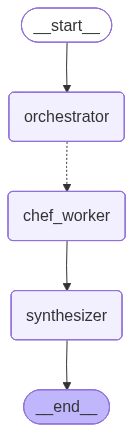

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	orchestrator(orchestrator)
	chef_worker(chef_worker)
	synthesizer(synthesizer)
	__end__([<p>__end__</p>]):::last
	__start__ --> orchestrator;
	chef_worker --> synthesizer;
	orchestrator -.-> chef_worker;
	synthesizer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [102]:
# compile the builder to get a complete workflow executable
from IPython.display import Image, display

orchestrator_worker = orchestrator_worker_builder.compile()
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))
print(orchestrator_worker.get_graph().draw_mermaid())

##### Testing (Orchestration)

Finally, we'll test the workflow by invoking it with a sample meal request to see the end-to-end meal planning process in action:

In [103]:
# invoke the workflow with a string of meals in a dict
state = orchestrator_worker.invoke({"meals": "Steak and eggs, tacos, and chili"})
# print the first 2000 characters of our final_meal_guide
pprint(state["final_meal_guide"][:2000])

/opt/homebrew/lib/python3.13/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Dishes(sections=[Dish(nam...], location='Tex-Mex')]), input_type=Dishes])
  return self.__pydantic_serializer__.to_python(


('**Hello! I’m Chef\u202fAlex Martinez, a New‑York‑based culinary professional '
 'with over 15\u202fyears of experience in classic American comfort cooking '
 'and contemporary brunch fare. I’ve spent my career perfecting the balance of '
 'bold, hearty flavors and simple techniques that let quality ingredients '
 'shine. Today I’m excited to walk you through a timeless favorite: **Steak & '
 'Eggs**—a protein‑packed plate that’s perfect for a leisurely weekend brunch '
 'or a satisfying dinner.**  \n'
 '\n'
 '---\n'
 '\n'
 '## Ingredients (for 2 servings)\n'
 '\n'
 '| Ingredient | Amount |\n'
 '|------------|--------|\n'
 '| Steak (ribeye, sirloin, or strip) | 8‑10\u202foz (≈\u202f225‑285\u202fg) '
 'per person |\n'
 '| Eggs | 2 per person |\n'
 '| Salt | to taste (≈\u202f½\u202ftsp) |\n'
 '| Freshly ground black pepper | to taste (≈\u202f¼‑½\u202ftsp) |\n'
 '| Butter | 1\u202fTbsp (plus a little extra for the eggs) |\n'
 '| Olive oil | 1\u202fTbsp (for searing) |\n'
 '\n'
 '*Optiona

### Reflection Pattern

The Reflection Pattern is an iterative loop where an AI generates an output, critiques it against defined criteria, and refines it until quality targets are met. 

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/9kH761sRFhuVPWzBUZhgkA/reflection.png" width="500" alt="reflection">

In this section, it’s used to build an investment advisor that repeatedly evaluates and improves portfolio recommendations to balance growth and risk before presenting a final suggestion.

##### State (Reflection)

As in earlier workflows, state tracks evolving values across steps. Here, the `State` dictionary stores the user’s investment profile, current plan, evaluator feedback, current risk/safety profile, target safety profile, and iteration counter `n`.

In [104]:
grades = Literal[
    "ultra-conservative", 
    "conservative", 
    "moderate", 
    "aggressive", 
    "high risk"
]

class State(TypedDict):
    investment_plan: str
    investor_profile: str
    target_grade: grades
    feedback: str
    grade: grades
    n: int = 0

##### Setup Node

Before the Generator and Evaluator nodes, add a setup node that assigns a suitable `target_grade` from the investor profile. This static value guides the workflow toward the desired direction; first build the prompt and chain to produce it.

In [105]:
grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an investment advisor. Given the investor’s profile and their proposed plan,"
     "choose exactly one risk classification from: ultra-conservative, conservative, moderate, aggressive, high risk."
     "Return ONLY the grade."
    ),
    ("user",
     "Investor profile:\n\n{investor_profile}\n\n"
    )
])

grade_pipe = grade_prompt | llm

In [106]:
def determine_target_grade(state: State):
    """Ask the LLM to pick the best-fitting target_grade."""
    response = grade_pipe.invoke({
        "investor_profile": state["investor_profile"]
    })
    
    # return as a plain dict so LangGraph can merge it into the state
    return {"target_grade": response.content.lower()}

In [107]:
# initialize empty state except for the user inputted investor profile
dummy_state: State = {
    "investment_plan": "",
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    ),
    "target_grade": "",
    "feedback": "",
    "grade": "",
    "n": 0
}

In [108]:
# get target grade
target_grade = determine_target_grade(dummy_state)
# update target grade with the returned dict
dummy_state.update(target_grade)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': '',
 'investor_profile': 'Age: 29\n'
                     'Salary: $110,000\n'
                     'Assets: $40,000\n'
                     'Goal: Achieve financial independence by age 45\n'
                     'Risk tolerance: High',
 'n': 0,
 'target_grade': 'high risk'}


#### Generator Node

The generator creates an investment plan from the investor profile, but as a multi-phase component: it starts bold, then gets refined through feedback.  

**Phase 1** uses a Cathie Wood-style prompt (high-growth, high-risk, tech-focused) with system + user messages chained into `cathie_wood_pipe`, producing the initial candidate strategy for later evaluation and refinement.

In [109]:
# inital generation, no feedback, only based on profile
cathie_wood_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are a bold, innovation-driven investment advisor inspired by Cathie Wood.

Your goal is to generate a high-conviction, forward-looking investment plan that embraces disruptive technologies,
emerging markets, and long-term growth potential. You are not afraid of short-term volatility as long as the upside is transformational.

Create an investment strategy tailored to the investor profile below. Prioritize innovation and high-reward opportunities,
such as artificial intelligence, biotechnology, blockchain, or renewable energy.

Respond with a concise investment plan in paragraph form.
"""
    ),
    ("human", "Investor profile:\n\n{investor_profile}")
])

cathie_wood_pipe = cathie_wood_prompt | llm

The generator’s second phase uses evaluator feedback, so first format the evaluator output into a structured `Feedback` schema for the next generation step.

In [110]:
# evaluator output schema
class Feedback(BaseModel):
    grade: grades = Field(
        description="Classify the investment based on risk level, ranging from ultra-conservative to high risk."
    )
    feedback: str = Field(
        description="Provide reasoning for the risk classification assigned to the investment suggestion."
    )

For **Phase 2: Adaptive Generation**, to refine the initial plan, add a Ray Dalio-style generator (more conservative, macro-focused) that takes evaluator `Feedback` (`grade`, `feedback`) plus `investor_profile` from state. It uses a conservative system message + a human message containing profile and feedback, chained in `ray_dalio_pipe`.

In [111]:
ray_dalio_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are an investment advisor inspired by Ray Dalio's principles but with adaptive strategy generation.
Your goal is to create varied, scenario-aware investment plans that respond dynamically to economic conditions,
feedback, and the investor's evolving needs. You adapt your recommendations based on previous evaluations.

CORE PRINCIPLES:
- Environmental diversification across economic regimes (growth/inflation combinations)
- Risk parity weighting by volatility, not just dollar amounts
- Inflation-aware asset selection with real return focus
- Macroeconomic scenario planning and regime identification

ADAPTATION RULES based on feedback:
- If deemed "too conservative" → Increase growth equity allocation, add emerging markets, consider alternatives
- If deemed "too aggressive" → Add defensive assets, increase bond allocation, focus on dividend stocks
- If "lacks inflation protection" → Emphasize TIPS, commodities, REITs, international exposure
- If "too complex" → Simplify to core ETF strategy with clear rationale
- If "insufficient diversification" → Add geographic, sector, or alternative asset exposure

ECONOMIC SCENARIO ADJUSTMENTS:
- Rising inflation environment → Emphasize commodities, TIPS, real estate, reduce duration
- Stagflation concerns → Focus on energy, materials, international markets, inflation hedges
- Deflationary risks → Increase government bonds, high-quality corporate bonds, cash positions
- Growth acceleration → Favor technology, consumer discretionary, small-cap growth
- Economic uncertainty → Balance with "All Weather" approach using multiple asset classes

TARGETING 15% RETURNS through:
- Strategic overweighting of growth assets during favorable conditions
- Tactical allocation adjustments based on economic regime
- Alternative investments (REITs, commodities, international) for diversification
- Leverage consideration for qualified investors
- Regular rebalancing to capture volatility

Respond with a clear, actionable investment plan that reflects current economic conditions 
and adapts to the specific feedback provided. Vary your approach significantly based on 
the grade and feedback received.
"""
    ),
    ("human",
     """Investor profile:
{investor_profile}

Previous strategy grade: {grade}

Evaluator feedback: {feedback}

Based on this feedback, create a NEW investment strategy that addresses the concerns raised 
while targeting 15% returns. Make significant adjustments from any previous approach.
""")
])

ray_dalio_pipe = ray_dalio_prompt | llm

##### Build the Generator Node

`investment_plan_generator` is a dynamic node that creates or refines strategy based on state.  
- If no feedback exists, it uses `cathie_wood_pipe` for an aggressive, high-growth initial plan.  
- If feedback exists, it uses `ray_dalio_pipe` with investor profile plus evaluator grade/feedback to produce a safer, improved revision.  

This enables iterative strategy improvement through reflection.

In [112]:
def investment_plan_generator(state: State) -> dict:
    """Prompts an LLM to generate or improve an investment plan based on the current state."""

    if state.get("feedback"):
        # use Ray Dalio–style generator when feedback is available
        response = ray_dalio_pipe.invoke({
            "investor_profile": state["investor_profile"],
            "grade": state["grade"],
            "feedback": state["feedback"]
        })
    else:
        # use Cathie Wood–style generator for initial plan
        response = cathie_wood_pipe.invoke({
            "investor_profile": state["investor_profile"]
        })

    return {"investment_plan": response.content}

In [113]:
# get the investment plan
initial_investment_plan = investment_plan_generator(dummy_state)
# update the dummy state with generated plan
dummy_state.update(initial_investment_plan)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': 'Given your youth, high income, sizable cash flow and '
                    'willingness to ride short‑term volatility, the plan is to '
                    'aim for a 15‑20\u202f% annual compound return by leaning '
                    'heavily into disruptive, high‑growth themes while still '
                    'keeping a core of diversified exposure to manage the '
                    'inevitable drawdowns. First, lock away three‑to‑six '
                    'months of living expenses in a high‑yield savings account '
                    'as an emergency buffer; the remainder of the $40\u202fk '
                    'cash base and all future earnings should flow directly '
                    'into tax‑advantaged accounts (max out a Roth IRA each '
                    'year – $6,500 in 2024 – and, if available, a solo 401(k) '
                    'or brokerage‑account “mega backdoor” to shelter as much '
                    'of your

##### Evaluator Node

The Evaluator Node reviews each generated investment plan using a Warren Buffett-style, conservative lens (capital preservation, fundamentals, long-term stability, low speculation).  

Given `investment_plan`, `investor_profile`, and `target_grade`, it outputs structured `Feedback` with:
- a risk **grade** (from predefined literals), and  
- concise **justification** explaining the assessment.

In [114]:
# Warren Buffet style evaluation prompt
evaluator_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """You are an investment risk evaluator inspired by Warren Buffett's value investing philosophy.

Your task is to assess whether a proposed investment strategy aligns with conservative, value-driven principles 
that emphasize capital preservation, long-term stability, and sound business fundamentals. You should be 
skeptical of speculative investments, high-volatility assets, and short-term market trends.

RISK CLASSIFICATION LEVELS:
- ultra-conservative: Extremely safe, minimal risk of loss
- conservative: Low risk, prioritizes capital preservation  
- moderate: Balanced approach with acceptable risk-reward ratio
- aggressive: Higher risk for potentially greater returns
- high risk: Speculative investments with significant loss potential

EVALUATION CRITERIA:
- Business clarity: Is the investment easily understandable with transparent cash flows?
- Margin of safety: Does the investment price provide protection against downside risk?
- Capital preservation: Will this strategy protect wealth over the long term?
- Investor alignment: Does this match a conservative investor's risk tolerance and goals?
- Quality fundamentals: Are the underlying assets financially sound with competitive advantages?

Return your assessment in the following  format:
{{
  "grade": "<investment risk level>",
  "feedback": "<concise explanation of the assigned risk level and key reasoning>"
}}
"""
    ),
    ("human", 
     "Evaluate this investment plan:\n\n{investment_plan}\n\nFor this investor profile:\n\n{investor_profile}\n\nAnd provide feedback that matches this target risk level: {target_grade}")
])

# create the pipe with the structured output that outputs a Feedback object
buffett_evaluator_pipe = evaluator_prompt | llm.with_structured_output(Feedback)

##### Build the Evaluator Node

`evaluate_plan` reviews the current `investment_plan` with a Buffett-style evaluator against `investor_profile` and `target_grade`, returns structured `grade` + justification `feedback`, and increments `n` to track reflection iterations.

In [115]:
def evaluate_plan(state: State):
    """LLM evaluates the investment plan"""

    # add one to the current count
    current_count = state.get('n', 0) + 1

    # get the evaluation result from the evaluator pipe
    evaluation_result = buffett_evaluator_pipe.invoke({
        "investment_plan": state["investment_plan"],
        "investor_profile": state["investor_profile"],
        "target_grade": state["target_grade"]
    })

    # return the grade and feedback in a dict
    return {"grade": evaluation_result.grade, "feedback": evaluation_result.feedback, "n": current_count}

In [116]:
# get the feedback
evaluated_feedback = evaluate_plan(dummy_state)
# update the dummy state with the feedback
dummy_state.update(evaluated_feedback)

In [117]:
print(f"Grade: {dummy_state["grade"]}")
print(f"Feedback: {dummy_state["feedback"]}")

Grade: high risk
Feedback: The strategy is heavily weighted toward speculative, high‑growth themes, private‑equity, and crypto, with little emphasis on margin of safety, stable cash flows, or durable competitive advantages. While the investor’s high risk tolerance and long horizon justify some volatility, the plan lacks the capital‑preservation focus and clear business fundamentals valued by a conservative, value‑investing approach, placing it firmly in the high‑risk category.


##### Routing Node

`route_investment` is the decision node that, after evaluation, decides to accept and end, send back for refinement, or stop after too many iterations. It compares evaluator `grade` with `target_grade` and also checks iteration count `n`.

In [118]:
def route_investment(state: State, iteration_limit: int = 5):
    """Route investment based on risk grade evaluation"""
    # get grades
    current_grade = state.get("grade", "MISSING")
    target_grade = state.get("target_grade", "MISSING")
    # check if grades match
    match = current_grade == target_grade

    # print out the tracked values
    print(f"=== ROUTING  ===")
    print(f"Current grade: '{current_grade}'")
    print(f"Target risk profile: '{target_grade}'")
    print(f"Match: {match}")
    print(f"Number of trials: {state['n']}")

    # routing logic
    if match: # grades match
        print("→ Routing to: Accepted")
        return "Accepted"
    elif state['n'] > iteration_limit: # review iterations exceeds limit
        print("→ Too many iterations, stopping")
        return "Accepted"
    else: # grades don't match
        print("→ Routing to: Rejected + Feedback")
        return "Rejected + Feedback"

##### Building the Workflow (Reflection)

Use a `StateGraph` reflection loop to iteratively improve investment strategies: generate a plan, evaluate it, and repeat until it matches the target grade (or stops by rule).

### Build Steps
1. Add nodes: `determine_target_grade`, `investment_plan_generator`, `evaluate_plan`.  
2. Add edges: `START → determine_target_grade → investment_plan_generator → evaluate_plan`.  
3. Add conditional routing to compare `grade` vs `target_grade` and either end or loop back for refinement.

In [122]:
# initialize StateGraph with the given State schema
optimizer_builder = StateGraph(State)

# add the setup, generator, and evaluator nodes
optimizer_builder.add_node("determine_target_grade", determine_target_grade)
optimizer_builder.add_node("investment_plan_generator", investment_plan_generator)
optimizer_builder.add_node("evaluate_plan", evaluate_plan)

# define the flow with edges
optimizer_builder.add_edge(START, "determine_target_grade")
optimizer_builder.add_edge("determine_target_grade", "investment_plan_generator")
optimizer_builder.add_edge("investment_plan_generator", "evaluate_plan")

##### Conditional Routing

Add a conditional edge from the evaluator to complete the reflection loop. It calls `route_investment` (via `lambda`) to compare `grade` vs `target_grade` and check iteration count.  
- Match: route to `END`  
- Mismatch: loop back to generator for revision  
- Max iterations reached: exit gracefully with the latest plan

In [123]:
# add conditional edge for reflection
optimizer_builder.add_conditional_edges(
    "evaluate_plan",
    lambda state: route_investment(state),
    {
        "Accepted": END,
        "Rejected + Feedback": "investment_plan_generator",
    },
)

In [124]:
# compile the workflow
optimizer_workflow = optimizer_builder.compile()

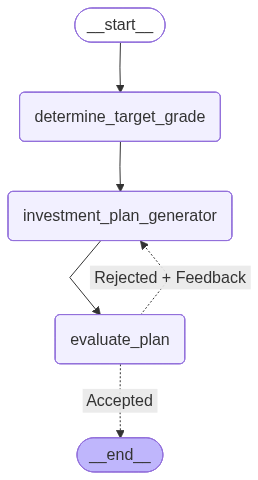

In [125]:
# display the graph
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

##### Testing (Reflection)

Test the workflow by invoking it with a sample investor profile to run the full end-to-end plan generation and refinement process.

In [126]:
# invoke the workflow with an example investor profile
state = optimizer_workflow.invoke({
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    )
})

=== ROUTING  ===
Current grade: 'high risk'
Target risk profile: 'high risk'
Match: True
Number of trials: 1
→ Routing to: Accepted


/opt/homebrew/lib/python3.13/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Feedback(grade='high risk... high‑risk strategy.'), input_type=Feedback])
  return self.__pydantic_serializer__.to_python(


In [127]:
def pretty_print_final_state(state: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Investor Profile:\n{state['investor_profile']}")
    
    print("\n📈 Target Risk Grade:", state['target_grade'])
    print("📊 Final Assigned Grade:", state['grade'])
    print("🔁 Iterations Taken:", state['n'])

    print("\n📝 Evaluator Feedback:\n" + "-"*30)
    print(state['feedback'])

    print("\n📃 Final Investment Plan:\n" + "-"*30)
    print(state['investment_plan'])

pretty_print_final_state(state)

🎯 Final Investment Plan Summary

📌 Investor Profile:
Age: 29
Salary: $110,000
Assets: $40,000
Goal: Achieve financial independence by age 45
Risk tolerance: High

📈 Target Risk Grade: high risk
📊 Final Assigned Grade: high risk
🔁 Iterations Taken: 1

📝 Evaluator Feedback:
------------------------------
The plan is heavily weighted toward speculative thematic ETFs, individual mega‑growth stocks, crypto and private‑equity, all of which lack clear cash‑flow visibility and margin of safety. The concentration in high‑volatility sectors and illiquid assets undermines capital preservation and does not align with conservative value‑investing principles, making it a high‑risk strategy.

📃 Final Investment Plan:
------------------------------
**Bold, Innovation‑First Roadmap to FI by 45**  
At 29 with a $110 k salary and $40 k of liquid assets, you can afford an aggressive, growth‑centric portfolio that leans heavily on disruptive themes while still keeping a safety net. First, lock in a **6‑mon